# Cross-validation

## Import packages

In [1]:
from importlib import reload
import os
import glob
import glob2
import pandas as pd
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 500)
import numpy as np
import sys
import hpfspec
import hpfspecmatch

DIRNAME: /home/tehan/PycharmProjects/hpfspecmatch
/home/tehan/PycharmProjects/hpfspecmatch/library/20210811_specmatch_nir/FITS


## Read in Library

In [2]:
# download library if does not exist
hpfspecmatch.utils.get_library()

Library already exists. Skipping download
Library path is: /home/tehan/PycharmProjects/hpfspecmatch/library/20210811_specmatch_nir


In [3]:
# List of stellar library fits files
library_fitsfiles = hpfspecmatch.config.LIBRARY_FITSFILES

# Read in all files as a HPFSpecList object
HLS = hpfspec.HPFSpecList(filelist=library_fitsfiles)

Reading from file /home/tehan/anaconda3/envs/hpf/lib/python3.7/site-packages/hpfspec/data/target_files/GJ_393.config
Barycentric shifting
RVabs iteration #1:  8.33333+- 0.00000km/s
RVabs iteration #2:  8.32934+- 0.00000km/s
berv=-25.48519199698786,rv=8.329341157525445
Reading from file /home/tehan/anaconda3/envs/hpf/lib/python3.7/site-packages/hpfspec/data/target_files/PM_J15118+3933.config
could not convert string to float: 'None' File does not exist!
Querying SIMBAD for data
Saving to file /home/tehan/anaconda3/envs/hpf/lib/python3.7/site-packages/hpfspec/data/target_files/PM_J15118+3933.config
ra 227.9644383333333
dec 39.55058777777778
pmra 96.187
pmdec -154.277
px 33.2582
rv None
epoch 2451545.0
Done
Barycentric shifting
RVabs iteration #1: -15.50000+- 0.00000km/s
RVabs iteration #2: -15.55166+- 0.00000km/s
berv=-10.608760365680746,rv=-15.5516591737958
Reading from file /home/tehan/anaconda3/envs/hpf/lib/python3.7/site-packages/hpfspec/data/target_files/GJ_699.config
Barycentric sh

In [4]:
HLS.splist

[HPFSpec(GJ_393,sn18=475.0),
 HPFSpec(PM_J15118+3933,sn18=74.3),
 HPFSpec(GJ_699,sn18=763.7),
 HPFSpec(GJ_908,sn18=593.3),
 HPFSpec(HD_233153,sn18=279.7),
 HPFSpec(GJ_172,sn18=599.4),
 HPFSpec(Teegarden,sn18=340.3),
 HPFSpec(PM_J02555+2652,sn18=147.9),
 HPFSpec(GJ_53.1_B,sn18=66.7),
 HPFSpec(PM_J16139+3346,sn18=213.0),
 HPFSpec(PM_J08526+2818,sn18=228.8),
 HPFSpec(GJ_213,sn18=598.8),
 HPFSpec(GJ_9304,sn18=468.5),
 HPFSpec(GJ_673,sn18=535.9),
 HPFSpec(GJ_507.1,sn18=350.9),
 HPFSpec(LSPM_J1105+4331W,sn18=295.9),
 HPFSpec(GJ_1148,sn18=409.2),
 HPFSpec(GJ_3991,sn18=455.4),
 HPFSpec(GJ_458.2,sn18=418.3),
 HPFSpec(GJ_480,sn18=377.4),
 HPFSpec(GJ_644_C,sn18=116.6),
 HPFSpec(LSPM_J1916+0510,sn18=288.4),
 HPFSpec(PM_J20034+2951,sn18=111.3),
 HPFSpec(PM_J20112+1611,sn18=132.3),
 HPFSpec(GJ_402,sn18=536.2),
 HPFSpec(GJ_3378,sn18=517.1),
 HPFSpec(GJ_905,sn18=507.8),
 HPFSpec(GJ_273,sn18=584.4),
 HPFSpec(HD_260655,sn18=567.2),
 HPFSpec(BD+00_444,sn18=345.0),
 HPFSpec(V*_V2689_Ori,sn18=314.6),
 HPFS

In [5]:
# Read in library 
df_lib = pd.read_csv(hpfspecmatch.config.PATH_LIBRARY_DB)
df_lib

,OBJECT,source,Teff,e_Teff,[Fe/H],e_[Fe/H],log(g),e_log(g),FILE,simbadnames_x,ID_NAME,OBJECT_ID,filename,exptime,sn18,qprog,rv,basenames,simbadnames_y
0,GJ_9066,Mann,3080.000,60.000,-0.160,0.08,5.053,0.053,/gpfs/group/cfb12/default/HPFData/Processed/Wa...,TIC_404715018|LSPM_J0200+1303|UCAC2__36403434|...,Gaia_DR2_76868614540049408,GJ_9066,../library/20210807_library/spec_mann/FITS/Slo...,969.15,487.130005,HET20-2-300,-28.569498,Slope-20200724T102147_R01.optimal.fits,TIC_404715018|LSPM_J0200+1303|UCAC2__36403434|...
1,Ross_128,Mann,3192.000,60.000,-0.020,0.08,5.076,0.050,/gpfs/group/cfb12/default/HPFData/Processed/Wa...,TIC_325275315|PLX_2730|LSPM_J1147+0048|ASCC_11...,Gaia_DR2_3796072592206250624,Ross_128,../library/20210807_library/spec_mann/FITS/Slo...,617.70,575.633179,ENG20-2-003,-31.078666,Slope-20200406T041204_R01.optimal.fits,TIC_325275315|PLX_2730|LSPM_J1147+0048|ASCC_11...
2,GJ_15_B,Mann,3218.000,60.000,-0.300,0.08,5.072,0.051,/gpfs/group/cfb12/default/HPFData/Processed/Wa...,TIC_440109718|ASCC__373580|2MASS_J00182549+440...,Gaia_DR2_385334196532776576,GJ_15_B,../library/20210807_library/spec_mann/FITS/Slo...,649.65,523.086914,ENG19-3-003,10.941464,Slope-20191119T060341_R01.optimal.fits,TIC_440109718|ASCC__373580|2MASS_J00182549+440...
3,GJ_105_B,Mann,3284.000,60.000,-0.120,0.03,4.941,0.049,/gpfs/group/cfb12/default/HPFData/Processed/Wa...,TIC_278962913|LSPM_J0236+0652|2MASS_J02361535+...,Gaia_DR2_18565464288396416,GJ_105_B,../library/20210807_library/spec_mann/FITS/Slo...,969.15,487.895020,PSU20-1-001,26.274138,Slope-20200108T040109_R01.optimal.fits,TIC_278962913|LSPM_J0236+0652|2MASS_J02361535+...
4,GJ_1148,Mann,3304.000,61.000,0.070,0.08,4.814,0.053,/gpfs/group/cfb12/default/HPFData/Processed/Wa...,TIC_115869504|WISEA_J114144.08+424506.2|Gaia_D...,Gaia_DR2_772430527947893632,GJ_1148,../library/20210807_library/spec_mann/FITS/Slo...,969.15,409.223083,PSU19-1-009,-9.053908,Slope-20190320T034635_R01.optimal.fits,TIC_115869504|WISEA_J114144.08+424506.2|Gaia_D...
5,GJ_273,Mann,3317.000,60.000,-0.110,0.08,4.894,0.049,/gpfs/group/cfb12/default/HPFData/Processed/Wa...,PLX_1755|LSPM_J0727+0513|ASCC_1029189|UCAC2__3...,Gaia_DR2_3139847906304421632,GJ_273,../library/20210807_library/spec_mann/FITS/Slo...,298.20,584.432251,ENG19-3-003,18.217935,Slope-20191115T091235_R01.optimal.fits,PLX_1755|LSPM_J0727+0513|ASCC_1029189|UCAC2__3...
6,GJ_4333,Mann,3324.000,60.000,0.240,0.08,4.792,0.052,/gpfs/group/cfb12/default/HPFData/Processed/Wa...,TIC_435198528|WISEA_J232137.05+171710.9|TYC_17...,Gaia_DR2_2817999068780218368,GJ_4333,../library/20210807_library/spec_mann/FITS/Slo...,969.15,407.903839,UT20-1-008,-6.457640,Slope-20191214T025528_R01.optimal.fits,TIC_435198528|WISEA_J232137.05+171710.9|TYC_17...
7,GJ_4070,Mann,3400.000,61.000,-0.160,0.08,4.814,0.053,/gpfs/group/cfb12/default/HPFData/Processed/Wa...,TIC_68396286|TYC_2637-58-1|PM_J18419+3149|StKM...,Gaia_DR2_2090085056523454464,GJ_4070,../library/20210807_library/spec_mann/FITS/Slo...,969.15,253.166351,UT20-1-008,-31.796430,Slope-20200310T112118_R01.optimal.fits,TIC_68396286|TYC_2637-58-1|PM_J18419+3149|StKM...
8,GJ_109,Mann,3405.000,60.000,-0.100,0.08,4.852,0.049,/gpfs/group/cfb12/default/HPFData/Processed/Wa...,TIC_436856183|PLX__555|LSPM_J0244+2531|ASCC__6...,Gaia_DR2_114207651462714880,GJ_109,../library/20210807_library/spec_mann/FITS/Slo...,649.65,539.878052,UT20-3-013,30.520946,Slope-20201105T090359_R01.optimal.fits,TIC_436856183|PLX__555|LSPM_J0244+2531|ASCC__6...
9,GJ_725_A,Von Braun,3407.000,15.000,-0.490,0.10,4.900,0.010,/gpfs/group/cfb12/default/HPFData/Processed/Wa...,TIC_359676790|PLX_4330|LSPM_J1842+5937N|ASCC__...,Gaia_DR2_2154880616773521408,GJ_725_A,../library/20210807_library/spec_mann/FITS/Slo...,181.05,573.123291,UT20-3-013,-0.736845,Slope-20200821T052005_R01.optimal.fits,TIC_359676790|PLX_4330|LSPM_J1842+5937N|ASCC__...


## Running Cross-validation for Order 17

In [6]:
# suppress plots in ipython notebook
# suppress plots in ipython notebook
%matplotlib agg

# run crossvalidation for order 17
order = '17'
df_lib_compare = hpfspecmatch.run_crossvalidation_for_orders(order, df_lib, HLS, plot_results = True)

0
##################
Saving results to /home/tehan/PycharmProjects/hpfspecmatch/library/20210811_specmatch_nir/crossval/o17_crossval/plots/
##################
/home/tehan/PycharmProjects/hpfspecmatch/library/20210811_specmatch_nir/crossval/o17_crossval/plots/ already exists.
##################
Running Chi2 loop
##################
First step: Matching target star to all library stars
##################
Optimization terminated successfully.
         Current function value: 1.621828
         Iterations: 2
         Function evaluations: 120
  1/165, Target = GJ_393             Library Star = PM_J15118+3933     chi2 =  1.622
Optimization terminated successfully.
         Current function value: 2.694355
         Iterations: 1
         Function evaluations: 54
  2/165, Target = GJ_393             Library Star = GJ_699             chi2 =  2.694
Optimization terminated successfully.
         Current function value: 1.383454
         Iterations: 1
         Function evaluations: 55
  3/165, Targ

## Plot 1D Performance 

plotting 1D crossval
std=81.19K
std=0.12dex
std=0.05dex


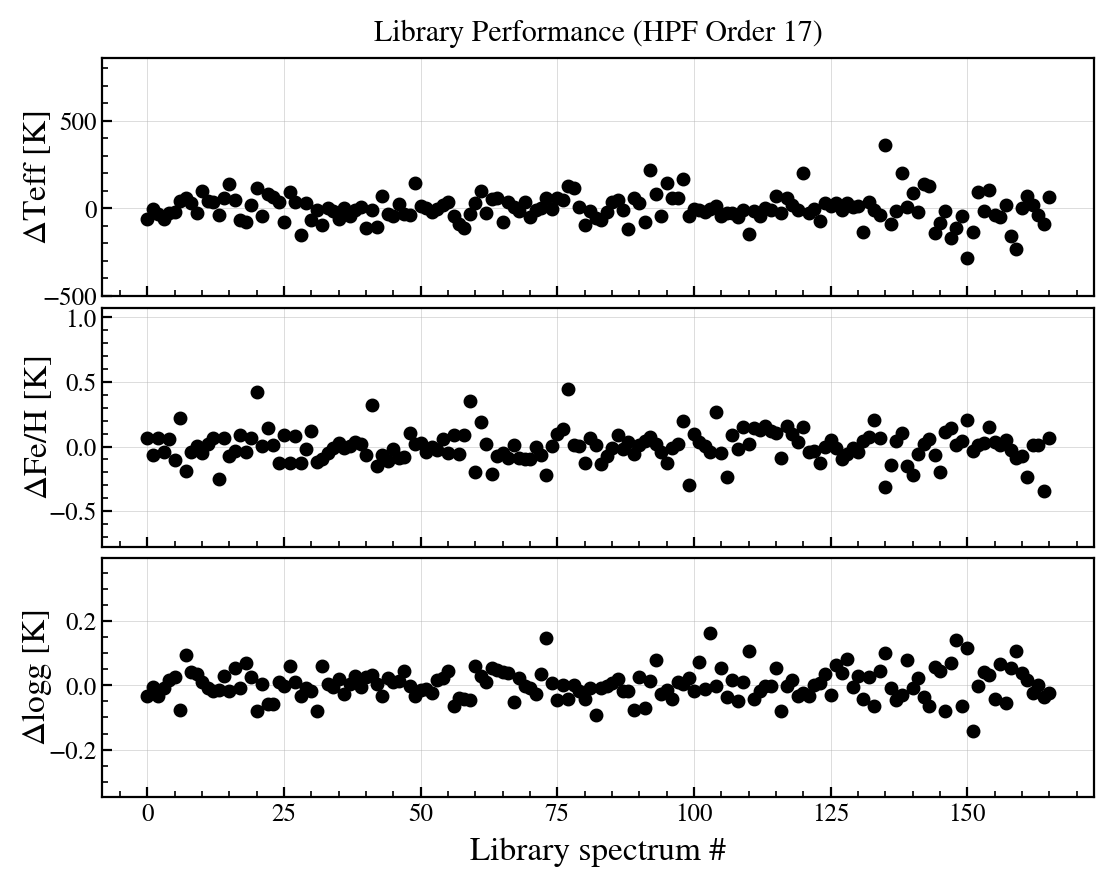

In [8]:
%matplotlib inline
order = '17'

csv_path = '..'+hpfspecmatch.config.PATH_LIBRARY[len(hpfspecmatch.config.DIRNAME):]+'/crossval/o{}_crossval/crossvalidation_results_o{}.csv'.format(order,order)
df_crossval = pd.read_csv(csv_path)

savefolder = '..'+hpfspecmatch.config.PATH_LIBRARY[len(hpfspecmatch.config.DIRNAME):]+'/crossval/o{}_crossval'.format(order)
hpfspecmatch.plot_crossvalidation_results_1d(order,df_crossval,savefolder)

## Plot 2D Performance

In [ ]:
order = '17'

csv_path = '..'+hpfspecmatch.config.PATH_LIBRARY[len(hpfspecmatch.config.DIRNAME):]+'/crossval/o{}_crossval/crossvalidation_resuls_o{}.csv'.format(order,order)
df_crossval = pd.read_csv(csv_path)

savefolder = '..'+hpfspecmatch.config.PATH_LIBRARY[len(hpfspecmatch.config.DIRNAME):]+'/crossval/o{}_crossval'.format(order)
hpfspecmatch.plot_crossvalidation_results_2d(order,df_crossval,savefolder)

## Cross-validation Errors 
- We should probably save these into a file that we can read in
- Should we add it to the 2D plot ?

In [ ]:
order = '17'
df_crossval = pd.read_csv('../library/20210406_specmatch_nir_library/crossval/o{}_crossval/crossvalidation_resuls_o{}.csv'.format(order,order))

In [ ]:
np.std(df_crossval.d_teff.values)

In [ ]:
np.std(df_crossval.d_feh)

In [ ]:
np.std(df_crossval.d_logg)